In [138]:
import numpy as np
import pandas as pd

### Implement cosine similarity while handling zero-norm vectors (to avoid $0/0$).

In [2]:
# u and v are vectors, and theta is the angle between the vectors
# cosine similarity = cos(theta) = u.T @ v / np.sqrt(u.T @ u) * np.sqrt(v.T @ v)

u = np.array([1,2,3,4,5])
v = np.array([2,4,6,8,10])

cosine_similaruty_uv = u.T @ v / np.sqrt(u.T @ u) * np.sqrt(v.T @ v)

cosine_similaruty_uv

np.float64(220.0)

In [3]:
u = np.array([0,0,0,0,0])
v = np.array([0,0,0,0,0])

def safe_cosine_similarity(u, v):

    if u.shape[0] != v.shape[0]:
        raise Exception("Shape of input vectors u and v does not match!")

    d = u.shape[0]
    u_zeros = np.zeros(d)
    v_zeros = np.zeros(d)

    if ((u == v).sum().item() == d) and ((u == u_zeros).sum().item() == d) and ((v == v_zeros).sum().item() == d):
        return 1
    else:
        return u.T @ v / np.sqrt(u.T @ u) * np.sqrt(v.T @ v)

safe_cosine_similarity(u, v)

1

### Compute an $N \times N$ pairwise (euclidean) distance matrix from an $N \times D$ input matrix without using for loops.

In [4]:
# euclidean_distance(u, v) = np.sqrt((u - v).T @ (u - v))

u = np.array([1,2,3,4,5])
v = np.array([2,4,6,8,10])

euclidean_distance_uv = np.sqrt((u-v).T @ (u-v))

euclidean_distance_uv

np.float64(7.416198487095663)

In [5]:
# note that euclidean_distance(u, v) = ||u-v||_2 = (u - v).T @ (u - v) = ||u||_2 + ||v||_2 - 2 * (u.T @ v)

M = np.array(
    [
        [1,2,3],
        [4,5,6]
    ]
)

In [6]:
(M * M).sum(axis=0, keepdims=True)

array([[17, 29, 45]])

In [7]:
(M * M).sum(axis=0, keepdims=True).T + (M * M).sum(axis=0, keepdims=True)

array([[34, 46, 62],
       [46, 58, 74],
       [62, 74, 90]])

In [8]:
2 * (M.T @ M)

array([[34, 44, 54],
       [44, 58, 72],
       [54, 72, 90]])

In [9]:
(M * M).sum(axis=0, keepdims=True).T + (M * M).sum(axis=0, keepdims=True) - 2 * (M.T @ M)

array([[0, 2, 8],
       [2, 0, 2],
       [8, 2, 0]])

### Numerical Debugging: Identify and fix a function outputting NaN or Inf by checking dtype, norm, and dot product stability.

#### 1

In [10]:
import numpy as np

def get_signal_weights(alphas):
    """
    Converts raw alpha scores into weights using Softmax.
    Formula: w_i = exp(alpha_i) / sum(exp(alpha_j))
    """
    # 1. Compute exponentials
    exp_alphas = np.exp(alphas)
    
    # 2. Compute sum (the denominator)
    denom = np.sum(exp_alphas)
    
    # 3. Normalize
    weights = exp_alphas / denom
    
    return weights

# --- Test Case that fails ---
# In macro, sometimes signals can be quite large if not scaled (e.g., basis points)
volatile_alphas = np.array([1000, 1001, 998], dtype=np.float64)

print("Weights:", get_signal_weights(volatile_alphas))
# Expected Output: [0.24, 0.66, 0.09] approx
# Actual Output: [nan, nan, nan]

Weights: [nan nan nan]


/var/folders/y5/gwwq15s92v97s_yvjxy3cqn40000gn/T/ipykernel_68851/3956572136.py:9: RuntimeWarning: overflow encountered in exp
  exp_alphas = np.exp(alphas)
/var/folders/y5/gwwq15s92v97s_yvjxy3cqn40000gn/T/ipykernel_68851/3956572136.py:15: RuntimeWarning: invalid value encountered in divide
  weights = exp_alphas / denom


In [ ]:
import numpy as np

def get_signal_weights(alphas):
    """
    Converts raw alpha scores into weights using Softmax.
    Formula: w_i = exp(alpha_i) / sum(exp(alpha_j))
    """

    shifted_alphas = alphas - np.max(alphas)

    # 1. Compute exponentials
    exp_alphas = np.exp(shifted_alphas)
    
    # 2. Compute sum (the denominator)
    denom = np.sum(exp_alphas)
    
    if denom == 0:
        return np.ones_like(alphas) / len(alphas)

    # 3. Normalize
    weights = exp_alphas / denom
    
    return weights

# --- Test Case that fails ---
# In macro, sometimes signals can be quite large if not scaled (e.g., basis points)
volatile_alphas = np.array([1000, 1001, 998], dtype=np.float32)

print("Weights:", get_signal_weights(volatile_alphas))
# Expected Output: [0.24, 0.66, 0.09] approx
# Actual Output: [nan, nan, nan]

Weights: [0.25949648 0.70538455 0.03511903]


In [12]:
# --- Test Case that fails ---
# In macro, sometimes signals can be quite large if not scaled (e.g., basis points)
volatile_alphas = np.array([0, 0, 0], dtype=np.float32)

print("Weights:", get_signal_weights(volatile_alphas))
# Expected Output: [0.24, 0.66, 0.09] approx
# Actual Output: [nan, nan, nan]

Weights: [0.33333334 0.33333334 0.33333334]


#### 2

In [381]:
import numpy as np

def get_min_var_weights(returns):
    """
    Computes minimum variance weights using the covariance matrix.
    returns: (T x N) array of asset returns
    """

    # check 3: how correlated are the features?
    # print(np.corrcoef(returns.T))

    # 1. Estimate Covariance Matrix
    sigma = np.cov(returns, rowvar=False)

    # check 4
    eigvals = np.linalg.eigvalsh(sigma)
    print("---------------------------------------------")
    print("Eigenvalues of Sigma")
    print(eigvals)
    print("---------------------------------------------")

    # check 1: is the covariane matrix full-rank?
    # Compare with rank under different tolerances
    print("Rank of Sigma with Different Singular Value Tolerance")
    for tol in [1e-6, 1e-9, 1e-12, 1e-15]:
        r = np.linalg.matrix_rank(sigma, tol=tol)
        print(tol, r)
    print("---------------------------------------------")

    # check 2: is the covariance matrix unstable?
    sigma_inner = sigma.T @ sigma
    eigenvals = np.linalg.eigvals(sigma_inner)
    eigenvals_nonzero = eigenvals[eigenvals > 0]
    singular_values = np.sqrt(eigenvals_nonzero)
    max_singval = singular_values.max().item()
    min_singval = singular_values.min().item()
    print("Condition Number of Sigma")
    print(max_singval / min_singval)
    print(np.linalg.cond(sigma))
    print("---------------------------------------------")

    # 2. Invert the matrix
    # This is where the code crashes or produces astronomical numbers
    sigma_inv = np.linalg.inv(sigma)
    
    # 3. Apply the formula
    ones = np.ones(sigma.shape[0])
    numerator = sigma_inv @ ones
    denominator = ones.T @ sigma_inv @ ones
    
    return numerator / denominator

# --- Test Case: Highly Correlated Macro Assets ---
# Imagine 3 assets that are almost identical (e.g., 9.5yr, 10yr, and 10.5yr bonds)
np.random.seed(42)
base_asset = np.random.normal(0, 0.01, 100)
# Assets 2 and 3 are 99.99% correlated with Asset 1
data = np.column_stack([
    base_asset, 
    base_asset + np.random.normal(0, 1e-7, 100), 
    base_asset + np.random.normal(0, 1e-7, 100)
])

weights = get_min_var_weights(data)
print("Weights:", weights)
print("---------------------------------------------")
# Expected: [0.33, 0.33, 0.33]
# Actual: [ 4.2e+12, -8.1e+12,  3.9e+12] (Extreme values or LinAlgError)

---------------------------------------------
Eigenvalues of Sigma
[3.27007909e-15 1.03056847e-14 2.47431108e-04]
---------------------------------------------
Rank of Sigma with Different Singular Value Tolerance
1e-06 1
1e-09 1
1e-12 1
1e-15 3
---------------------------------------------
Condition Number of Sigma
416782557.2024779
75665723100.28194
---------------------------------------------
Weights: [  3245.41271862  12342.25358645 -15586.66630507]
---------------------------------------------


In [382]:
import numpy as np

def get_min_var_weights(returns):
    """
    Computes minimum variance weights using the covariance matrix.
    returns: (T x N) array of asset returns
    """

    # check 3: how correlated are the features?
    # print(np.corrcoef(returns.T))

    # 1. Estimate Covariance Matrix
    sigma = np.cov(returns, rowvar=False)
    epsilon = 1e-4
    sigma = sigma + np.eye(sigma.shape[0]) * epsilon

    # check 4
    eigvals = np.linalg.eigvalsh(sigma)
    print("---------------------------------------------")
    print("Eigenvalues of Sigma_ridge")
    print(eigvals)
    print("---------------------------------------------")

    # check 1: is the covariane matrix full-rank?
    # Compare with rank under different tolerances
    print("Rank of Sigma_ridge with Different Singular Value Tolerance")
    for tol in [1e-6, 1e-9, 1e-12, 1e-15]:
        r = np.linalg.matrix_rank(sigma, tol=tol)
        print(tol, r)
    print("---------------------------------------------")

    # check 2: is the covariance matrix unstable?
    sigma_inner = sigma.T @ sigma
    eigenvals = np.linalg.eigvals(sigma_inner)
    eigenvals_nonzero = eigenvals[eigenvals > 0]
    singular_values = np.sqrt(eigenvals_nonzero)
    max_singval = singular_values.max().item()
    min_singval = singular_values.min().item()
    print("Condition Number of Sigma_ridge")
    print(max_singval / min_singval)
    print("---------------------------------------------")

    # 2. Invert the matrix
    # This is where the code crashes or produces astronomical numbers
    sigma_inv = np.linalg.inv(sigma)
    
    # 3. Apply the formula
    ones = np.ones(sigma.shape[0])
    numerator = sigma_inv @ ones
    denominator = ones.T @ sigma_inv @ ones
    
    return numerator / denominator

# --- Test Case: Highly Correlated Macro Assets ---
# Imagine 3 assets that are almost identical (e.g., 9.5yr, 10yr, and 10.5yr bonds)
np.random.seed(42)
base_asset = np.random.normal(0, 0.01, 100)
# Assets 2 and 3 are 99.99% correlated with Asset 1
data = np.column_stack([
    base_asset, 
    base_asset + np.random.normal(0, 1e-7, 100), 
    base_asset + np.random.normal(0, 1e-7, 100)
])

weights = get_min_var_weights(data)
print("Weights:", weights)
print("---------------------------------------------")
# Expected: [0.33, 0.33, 0.33]
# Actual: [ 4.2e+12, -8.1e+12,  3.9e+12] (Extreme values or LinAlgError)

---------------------------------------------
Eigenvalues of Sigma_ridge
[0.0001     0.0001     0.00034743]
---------------------------------------------
Rank of Sigma_ridge with Different Singular Value Tolerance
1e-06 3
1e-09 3
1e-12 3
1e-15 3
---------------------------------------------
Condition Number of Sigma_ridge
3.474311076210843
---------------------------------------------
Weights: [0.33333357 0.33333475 0.33333169]
---------------------------------------------


In [40]:
import numpy as np

def get_min_var_weights(returns):
    """
    Computes minimum variance weights using the covariance matrix.
    returns: (T x N) array of asset returns
    """

    # check 3: how correlated are the features?
    # print(np.corrcoef(returns.T))

    # 1. Estimate Covariance Matrix
    sigma = np.cov(returns, rowvar=False)

    # check 4
    eigvals = np.linalg.eigvalsh(sigma)
    print("---------------------------------------------")
    print("Eigenvalues of Sigma")
    print(eigvals)
    print("---------------------------------------------")

    # check 1: is the covariane matrix full-rank?
    # Compare with rank under different tolerances
    print("Rank of Sigma with Different Singular Value Tolerance")
    for tol in [1e-6, 1e-9, 1e-12, 1e-15]:
        r = np.linalg.matrix_rank(sigma, tol=tol)
        print(tol, r)
    print("---------------------------------------------")

    # check 2: is the covariance matrix unstable?
    sigma_inner = sigma.T @ sigma
    eigenvals = np.linalg.eigvals(sigma_inner)
    eigenvals_nonzero = eigenvals[eigenvals > 0]
    singular_values = np.sqrt(eigenvals_nonzero)
    max_singval = singular_values.max().item()
    min_singval = singular_values.min().item()
    print("Condition Number of Sigma")
    print(max_singval / min_singval)
    print("---------------------------------------------")

    # 2. Invert the matrix
    # This is where the code crashes or produces astronomical numbers
    sigma_inv = np.linalg.pinv(sigma)
    
    # 3. Apply the formula
    ones = np.ones(sigma.shape[0])
    numerator = sigma_inv @ ones
    denominator = ones.T @ sigma_inv @ ones
    
    return numerator / denominator

# --- Test Case: Highly Correlated Macro Assets ---
# Imagine 3 assets that are almost identical (e.g., 9.5yr, 10yr, and 10.5yr bonds)
np.random.seed(42)
base_asset = np.random.normal(0, 0.01, 100)
# Assets 2 and 3 are 99.99% correlated with Asset 1
data = np.column_stack([
    base_asset, 
    base_asset + np.random.normal(0, 1e-7, 100), 
    base_asset + np.random.normal(0, 1e-7, 100)
])

weights = get_min_var_weights(data)
print("Weights using Pseudo Inverse:", weights)
print("---------------------------------------------")
# Expected: [0.33, 0.33, 0.33]
# Actual: [ 4.2e+12, -8.1e+12,  3.9e+12] (Extreme values or LinAlgError)

---------------------------------------------
Eigenvalues of Sigma
[3.27007909e-15 1.03056847e-14 2.47431108e-04]
---------------------------------------------
Rank of Sigma with Different Singular Value Tolerance
1e-06 1
1e-09 1
1e-12 1
1e-15 3
---------------------------------------------
Condition Number of Sigma
416782557.2024779
---------------------------------------------
Weights using Pseudo Inverse: [  3245.44622658  12342.19949742 -15586.64572522]
---------------------------------------------


#### 3

In [52]:
import pandas as pd
import numpy as np

np.random.seed(19940202)
# Setup dummy data
dates = pd.date_range('2023-01-01', '2023-06-01', freq='D')
returns = pd.Series(np.random.normal(0, 0.01, len(dates)), index=dates)

# Monthly Inflation data (Target)
monthly_inflation = pd.Series([0.02, 0.021, 0.019, 0.023, 0.025], 
                              index=pd.date_range('2023-01-01', periods=5, freq='MS'))

def compute_strategy_returns(returns, inflation):
    # 1. Align the data
    # 'ffill' carries the monthly value forward to all days in that month
    df = pd.DataFrame({'returns': returns, 'inflation': inflation})
    df['inflation'] = df['inflation'].ffill()
    
    # 2. Simple strategy: If inflation is rising, go long (1), else short (-1)
    df['signal'] = np.where(df['inflation'].diff() > 0, 1, -1)
    
    # 3. Compute strategy performance
    df['strat_ret'] = df['signal'] * df['returns']
    return df.dropna()

# Run the test
results = compute_strategy_returns(returns, monthly_inflation)
print(results.head(40))

             returns  inflation  signal  strat_ret
2023-01-01  0.003941      0.020      -1  -0.003941
2023-01-02  0.005420      0.020      -1  -0.005420
2023-01-03  0.002888      0.020      -1  -0.002888
2023-01-04  0.009085      0.020      -1  -0.009085
2023-01-05  0.003832      0.020      -1  -0.003832
2023-01-06 -0.012940      0.020      -1   0.012940
2023-01-07  0.012236      0.020      -1  -0.012236
2023-01-08  0.005154      0.020      -1  -0.005154
2023-01-09 -0.012399      0.020      -1   0.012399
2023-01-10 -0.004497      0.020      -1   0.004497
2023-01-11 -0.002641      0.020      -1   0.002641
2023-01-12  0.002383      0.020      -1  -0.002383
2023-01-13  0.007909      0.020      -1  -0.007909
2023-01-14  0.003835      0.020      -1  -0.003835
2023-01-15 -0.001191      0.020      -1   0.001191
2023-01-16  0.008610      0.020      -1  -0.008610
2023-01-17  0.007308      0.020      -1  -0.007308
2023-01-18  0.006859      0.020      -1  -0.006859
2023-01-19  0.006489      0.020

In [56]:
def safe_compute_strategy_returns(returns, inflation):
    # 1. Align the data
    # 'ffill' carries the monthly value forward to all days in that month
    df = pd.DataFrame({'returns': returns, 'inflation': inflation})
    df['inflation'] = df['inflation'].ffill()
    
    # 2. Simple strategy: If inflation is rising, go long (1), else short (-1)
    df['signal'] = np.where(df['inflation'].diff() > 0, 1, -1)
    
    # 3. Compute strategy performance
    df['strat_ret'] = df['signal'].shift(1) * df['returns']
    return df.dropna()

# Run the test
results_safe = compute_strategy_returns(returns, monthly_inflation)
print(results.head(40))


             returns  inflation  signal  strat_ret
2023-01-01  0.003941      0.020      -1  -0.003941
2023-01-02  0.005420      0.020      -1  -0.005420
2023-01-03  0.002888      0.020      -1  -0.002888
2023-01-04  0.009085      0.020      -1  -0.009085
2023-01-05  0.003832      0.020      -1  -0.003832
2023-01-06 -0.012940      0.020      -1   0.012940
2023-01-07  0.012236      0.020      -1  -0.012236
2023-01-08  0.005154      0.020      -1  -0.005154
2023-01-09 -0.012399      0.020      -1   0.012399
2023-01-10 -0.004497      0.020      -1   0.004497
2023-01-11 -0.002641      0.020      -1   0.002641
2023-01-12  0.002383      0.020      -1  -0.002383
2023-01-13  0.007909      0.020      -1  -0.007909
2023-01-14  0.003835      0.020      -1  -0.003835
2023-01-15 -0.001191      0.020      -1   0.001191
2023-01-16  0.008610      0.020      -1  -0.008610
2023-01-17  0.007308      0.020      -1  -0.007308
2023-01-18  0.006859      0.020      -1  -0.006859
2023-01-19  0.006489      0.020

<Axes: >

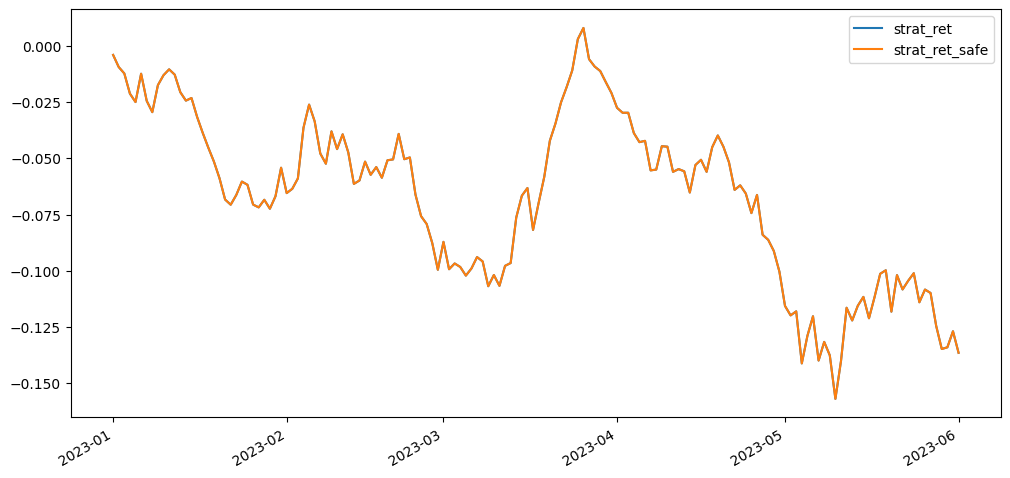

In [60]:
plot_df = pd.concat(
    [
        results[['strat_ret']].rename(columns={'strat_ret': 'strat_ret'}),
        results_safe[['strat_ret']].rename(columns={'strat_ret': 'strat_ret_safe'})
    ]
)

((1+plot_df).cumprod()-1).plot(figsize=(12, 6))

### 7. Two Sum (Target Pairs): Find all pairs in an array that sum to a target value in $O(n)$ time.

In [ ]:
def find_all_values_that_match_target(u, target):
    n, d = u.shape[0], u.shape[0]

    out = []
    i, j = 0, 0
    for i in range(n):
        for j in range(d):
            s = u[i] + u[j]
            if s == target:
                out.append((u[i].item(), u[j].item()))
                
    return out

u = np.array([1,2,3,4,5])
target = 10

find_all_values_that_match_target(u, target)

[(5, 5)]

In [99]:
def find_all_values_that_match_target(u, target):    
    
    out = []
    for x in u:
        m = target - x
        if m in u:
            out.append((x.item(), m.item()))

    return out

u = np.array([1,2,3,5,5])
target = 4

find_all_values_that_match_target(u, target)

[(1, 3), (2, 2), (3, 1)]

### Smallest Missing Positive Integer: Find the smallest positive integer not in an unsorted array in $O(n)$ time and $O(1)$ space.

(2.0,
 [(np.int64(5), np.int64(7)),
  (np.int64(5), np.int64(4)),
  (np.int64(5), np.int64(2)),
  (np.int64(2), np.int64(7)),
  (np.int64(2), np.int64(4)),
  (np.int64(4), np.int64(7))])

In [107]:
x = 5
len(u)

4

### Rolling Correlation at Scale: Implement an O(T) rolling correlation using cumulative sums. Discuss bottlenecks and scaling for T = $10^6$.

In [64]:
# population version: corr(x, y) = cov(x,y) / sqrt(var(x)var(y))
# sample version: corr(x, y) = ( \sum_{i}^{T} (x_i - \bar{x})(y_i - \bar{y}) ) / \sqrt{ ( \sum_{i}^{T}(x_i - \bar{x})^2 \sum_{i}^{T}(y_i - \bar{y})^2 ) }

np.random.seed(10)
dataset = np.random.multivariate_normal([0, 0], np.eye(2), (100, ))

x = dataset[:,0]
y = dataset[:,1]

# function args
cumulative = True

# function insider
T = x.shape[0] if (x.shape[0] == y.shape[0]) else print("Dimensions of x and y do not match.")
t0 = 0

corr_xy_ts = []
for t in range(2, T-1):                                                                         # \sum_{t=2}^{T} O(t) = O(T(T+1)/2) = O(T^2)
    x_current = x[t0:t]
    y_current = y[t0:t]

    cov_xy = np.sum((x_current - np.mean(x_current)) * (y_current - np.mean(y_current)))        # O(t): has to run all elements to compute means and sums
    std_x = np.sum((x_current - np.mean(x_current))**2)                                         # O(t): has to run all elements to compute means and sums
    std_y = np.sum((y_current - np.mean(y_current))**2)                                         # O(t): has to run all elements to compute means and sums
    corr_xy = cov_xy / (std_x * std_y)

    if not cumulative:
        t0 += 1

    corr_xy_ts.append(corr_xy)
corr_xy_ts = np.array(corr_xy_ts)

In [116]:
np.random.seed(10)
dataset = np.random.multivariate_normal([0, 0], np.eye(2), (100,))
x = dataset[:, 0]
y = dataset[:, 1]

T = x.shape[0]
if T != y.shape[0]:
    raise ValueError("Dimensions of x and y do not match.")

# prefix sums
sx  = np.cumsum(x)
sy  = np.cumsum(y)
sxx = np.cumsum(x * x)
syy = np.cumsum(y * y)
sxy = np.cumsum(x * y)

n = np.arange(1, T + 1, dtype=float)

# centered sums (a.k.a. "sum of squares/cross-products around the mean")
Sxx = sxx - (sx * sx) / n
Syy = syy - (sy * sy) / n
Sxy = sxy - (sx * sy) / n

denom = np.sqrt(Sxx * Syy)
corr = np.full(T, np.nan)
corr[1:] = Sxy[1:] / denom[1:]

In [117]:
corr

array([        nan,  1.        ,  0.24162999,  0.2452543 ,  0.25286775,
        0.26357167,  0.00733669,  0.01338031,  0.05578232, -0.25836016,
        0.18178296,  0.20364525,  0.29140705,  0.28714295,  0.28196304,
        0.28916199,  0.27667081,  0.25532696,  0.24042636,  0.16616989,
        0.14905454,  0.17886135,  0.1904702 ,  0.18598853,  0.17760273,
        0.17665737,  0.15730984,  0.15683136,  0.21075804,  0.21504822,
        0.22255794,  0.18296427,  0.18734516,  0.12775005,  0.1304899 ,
        0.13221512,  0.11688506,  0.11762829,  0.08774843,  0.11795873,
        0.1906364 ,  0.20129648,  0.19692448,  0.19574174,  0.17973376,
        0.181458  ,  0.18330727,  0.19260496,  0.19159903,  0.15199435,
        0.14696843,  0.13493412,  0.13665873,  0.12887391,  0.11790252,
        0.11586997,  0.07806578,  0.0806059 ,  0.07853195,  0.07270142,
        0.08722477,  0.12918901,  0.13490176,  0.13664751,  0.14983714,
        0.15572728,  0.15024907,  0.15201471,  0.1512628 ,  0.18

### Outlier Handling with Documentation: Implement Median Absolute Deviation and winsoriza-tion for heavy-tailed macro series. Document your choice of constants and edge cases.

In [ ]:
np.random.seed(10)
dataset = np.random.multivariate_normal([0, 0], np.eye(2), (100,))
x = dataset[:, 0]
y = dataset[:, 1]

outlier_indices_x = np.random.randint(0, dataset.shape[0], 10)
outlier_indices_y = np.random.randint(0, dataset.shape[0], 10)

for i in range(len(outlier_indices_x)):
    idx_x = outlier_indices_x[i]
    idx_y = outlier_indices_y[i]

    dataset[idx_x, 0] = np.random.normal(0, 100)
    dataset[idx_y, 1] = np.random.normal(0, 100)

df = pd.DataFrame(dataset, columns=['x', 'y'])

# AD_i = abs(x_i - median(x))
# MAD = median( abs(x_i - median(x)) )
# MAD_FILTER_i = "outlier" if (AD_i / MAD) > threshold else "not outlier"

threshold = 2
rolling_median = df.rolling(window=10).median()
absolute_difference = df.subtract(rolling_median).abs()
mad = absolute_difference.rolling(window=10).median()
mad_safe = mad.mask(mad <= 0, np.nan)

# --- Winsorization: cap to median ± threshold * MAD (per time, per column) ---
lower = rolling_median - threshold * mad_safe
upper = rolling_median + threshold * mad_safe

# outliers are replaced with lower/upper
df_winsor = df.clip(lower=lower, upper=upper)

### PCA via SVD: Given a standardized T × N panel, extract top-k factors and loadings; verifyshapes and reconstruction. Use a provided macro dataset.

In [ ]:
np.random.seed(10)

p = 10
X = np.random.multivariate_normal(np.ones(p), np.eye(p), (100,))

# U: left singular vectors (factors) in the sample space
# V: right singular vectors (loadings) in feature space
# S: vector of singular values
U, S, V = np.linalg.svd(X)

k = 2
topk_factors = U[:, :k]

loadings = V[:k, :].T

### Ridge in Closed Form: Implement ridge regression with train-only standardization. Test on a dataset with multicollinearity.

In [211]:
np.random.seed(10)

y_train = np.random.normal(0, 1, 100)
y_train = np.asmatrix(y_train).T
X_train = np.random.multivariate_normal(np.ones(p), np.eye(p), (100,))
p = X_train.shape[1]
X_train[:, p-3] = X_train[:, 0]
X_train[:, p-2] = X_train[:, 0]
X_train[:, p-1] = X_train[:, 0]

mean_X_train = np.mean(X_train, axis=0, keepdims=True)
std_X_train = np.std(X_train, axis=0, keepdims=True)
X_train_zscore = (X_train - mean_X_train) / std_X_train

X_test = np.random.multivariate_normal(np.ones(p), np.eye(p), (1,))
p = X_test.shape[1]
X_test[:, p-3] = X_test[:, 0]
X_test[:, p-2] = X_test[:, 0]
X_test[:, p-1] = X_test[:, 0]

X_test_zscore = (X_test - mean_X_train) / std_X_train

alpha = 100
ridge_reg_matrix = np.eye(p) * alpha
beta_ridge = np.linalg.inv(X.T @ X + ridge_reg_matrix) @ X.T @ y

y_test_fit = X_test_zscore @ beta_ridge

In [213]:
y_test_fit

matrix([[-0.02304057]])

### Sanity Checks: Detect non-PSD covariance estimates and handle near-singular matrices. Justify your approach for a macroeconomic covariance matrix.

In [219]:
X_train = np.random.multivariate_normal(np.ones(p), np.eye(p), (100,))
p = X_train.shape[1]
X_train[:, p-3] = X_train[:, 0]
X_train[:, p-2] = X_train[:, 0]
X_train[:, p-1] = X_train[:, 0]

U, S, V = np.linalg.svd(X_train.T @ X_train)

eigenvalues = S**2

threshold = 1e-6
eigenvalues >= threshold

array([ True,  True,  True,  True,  True,  True,  True, False, False,
       False])

###  Walk-Forward Splits: Implement a generator that yields train/test indices for rolling or expanding windows; no random CV. Include a test case with a provided dataset

In [244]:
# data = np.random.multivariate_normal(np.ones(p), np.eye(p), (100,))
data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def windows(data, step, expanding_window):
    # yield x pauses the function, gives back one value, and remembers where it stopped.

    for i in range(len(data) - step + 1):
        if not expanding_window:
            yield (data[i:i+step], data[i+step:i+step+step])
        else:
            yield (data[0:i+step], data[i+step:i+step+step])

print("------------------------")
print("Expanding-Window Generator")
for w in windows(data=data, step=3, expanding_window=True):
    print(w)

print("------------------------")
print("Rolling-Window Generator")
for w in windows(data=data, step=3, expanding_window=False):
    print(w)

------------------------
Expanding-Window Generator
([1, 2, 3], [4, 5, 6])
([1, 2, 3, 4], [5, 6, 7])
([1, 2, 3, 4, 5], [6, 7, 8])
([1, 2, 3, 4, 5, 6], [7, 8, 9])
([1, 2, 3, 4, 5, 6, 7], [8, 9, 10])
([1, 2, 3, 4, 5, 6, 7, 8], [9, 10])
([1, 2, 3, 4, 5, 6, 7, 8, 9], [10])
([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [])
------------------------
Rolling-Window Generator
([1, 2, 3], [4, 5, 6])
([2, 3, 4], [5, 6, 7])
([3, 4, 5], [6, 7, 8])
([4, 5, 6], [7, 8, 9])
([5, 6, 7], [8, 9, 10])
([6, 7, 8], [9, 10])
([7, 8, 9], [10])
([8, 9, 10], [])


### Purged/Embargoed CV with Example: Implement a split with a purge window/embargo.Apply to a dataset with serial correlation and explain your choices.

In [252]:
# data = np.random.multivariate_normal(np.ones(p), np.eye(p), (100,))
data = [1, 2, 3, 4, 5, 7, 8, 9, 10]
step = 4
embargo = 2

def windows_cv_embargoed(data, step, embargo, expanding_window):
    # yield x pauses the function, gives back one value, and remembers where it stopped.

    for i in range(len(data) - step + 1):
        if not expanding_window:
            yield (data[i:i+step-embargo], data[i+step:i+step+step])
        else:
            yield (data[0:i+step-embargo], data[i+step:i+step+step])

print("------------------------")
print("Expanding-Window Generator")
for w in windows_cv_embargoed(data=data, step=step, embargo=embargo, expanding_window=True):
    print(w)

print("------------------------")
print("Rolling-Window Generator")
for w in windows_cv_embargoed(data=data, step=step, embargo=embargo, expanding_window=False):
    print(w)

------------------------
Expanding-Window Generator
([1, 2], [5, 7, 8, 9])
([1, 2, 3], [7, 8, 9, 10])
([1, 2, 3, 4], [8, 9, 10])
([1, 2, 3, 4, 5], [9, 10])
([1, 2, 3, 4, 5, 7], [10])
([1, 2, 3, 4, 5, 7, 8], [])
------------------------
Rolling-Window Generator
([1, 2], [5, 7, 8, 9])
([2, 3], [7, 8, 9, 10])
([3, 4], [8, 9, 10])
([4, 5], [9, 10])
([5, 7], [10])
([7, 8], [])


### Forecast Metrics with Interpretation: Implement MAE, RMSE, and directional accuracy. Discuss which metrics are most relevant for GDP vs. inflation forecasting

In [ ]:
X = np.asmatrix(np.random.normal(0, 10, 100)).T
y = np.asmatrix(np.asmatrix(0.5).T @ X.T + np.random.normal(0, 1, 100)).T

y_pred = X @ (np.linalg.inv(X.T @ X) @ X.T @ y)

# MAE - Penalizes mispredictions proportionally to the size of the miss (e.g., 1% error is weighted twice as much as a 0.5% error)
mae = np.mean(np.abs(y - y_pred))

# RMSE - Heavily penalizes large mispredictions
rmse = np.sqrt(np.mean(np.power((y - y_pred), 2)))

# direction acurracy - Sign of the rate of change (e.g., contraction GDP quarters vs growing GDP quarters)
direction_accuracy = np.where(
    (y > 0) & (y_pred > 0), 1,
    np.where(
        (y < 0) & (y_pred < 0), 1,
        0
    )
)
direction_accuracy = (direction_accuracy.sum(axis=0) / direction_accuracy.shape[0]).item()

print('---')
print(f'MAE: {mae}')
print('---')
print(f'RMSE: {rmse}')
print('---')
print(f'Directional Accuracy: {direction_accuracy}')

---
MAE: 0.8884292188508907
---
RMSE: 1.097393451761753
---
Directional Accuracy: 0.92


### As-Of Join (Point-in-Time): Align daily market data with macro releases using an “as-of” merge. Use a provided dataset with timestamps and release lags.

In [328]:
import pandas as pd
import numpy as np

# Set seed for consistency
np.random.seed(42)

# 1. GENERATE MARKET DATA (The "Left" Table)
# Daily stock prices - high frequency
market_dates = pd.date_range(start='2023-01-01', end='2023-04-30', freq='D')
market_df = pd.DataFrame({
    'timestamp': market_dates,
    'price': 100 + np.cumsum(np.random.normal(0, 1.5, len(market_dates)))
}).sort_values('timestamp')

# 2. GENERATE MACRO DATA (The "Right" Table)
# Macro releases - low frequency (Monthly)
macro_release_dates = pd.to_datetime(['2023-01-31', '2023-02-28', '2023-03-31'])

macro_df = pd.DataFrame({
    'event_date': macro_release_dates,
    'ticker': 'CPI_YOY',
    'actual_value': [6.4, 6.0, 5.0],
    # 'lag_days' simulates the time it takes for the govt to process and release data
    'lag_days': [14, 12, 13] 
})

# Crucial: Calculate when the data was ACTUALLY known to the market
macro_df['pub_date'] = macro_df['event_date'] + pd.to_timedelta(macro_df['lag_days'], unit='D')

# SOLUTION
market_df = market_df.sort_values('timestamp')
macro_df = macro_df.sort_values('pub_date')

merge_df = pd.merge_asof(market_df, macro_df, left_on='timestamp', right_on='pub_date', direction='backward')

In [320]:
macro_df

,event_date,ticker,actual_value,lag_days,pub_date,timestamp
0,2023-01-31,CPI_YOY,6.4,14,2023-02-14,2023-02-14
1,2023-02-28,CPI_YOY,6.0,12,2023-03-12,2023-03-12
2,2023-03-31,CPI_YOY,5.0,13,2023-04-13,2023-04-13


In [326]:
merge_df.loc[merge_df['timestamp'] >= "2023-04-12"]

,timestamp,price,event_date,ticker,actual_value,lag_days,pub_date
101,2023-04-12,81.668998,2023-02-28,CPI_YOY,6.0,12.0,2023-03-12
102,2023-04-13,81.154927,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
103,2023-04-14,79.951511,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
104,2023-04-15,79.709582,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
105,2023-04-16,80.315658,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
106,2023-04-17,83.144937,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
107,2023-04-18,83.406804,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
108,2023-04-19,83.793129,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
109,2023-04-20,83.681461,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13
110,2023-04-21,80.803304,2023-03-31,CPI_YOY,5.0,13.0,2023-04-13


### Ragged Edge Feature Matrix: Build a daily feature panel where each indicator updates only on its release schedule. Document your handling of missing data.

In [362]:
import pandas as pd
import numpy as np

# 1. SETUP: Generate the Ragged Dataset
dates = pd.date_range('2023-01-01', '2023-03-31', freq='D')
panel = pd.DataFrame({'timestamp': dates})

# Mock High-Freq Data (Daily Price)
market_df = pd.DataFrame({
    'timestamp': dates,
    'price': 100 + np.cumsum(np.random.normal(0, 1, len(dates)))
})

# Mock Low-Freq Data (Monthly CPI - released with 15 day lag)
cpi_df = pd.DataFrame({
    'pub_date': pd.to_datetime(['2023-01-15', '2023-02-15', '2023-03-15']),
    'cpi_yoy': [6.5, 6.4, 6.0]
})

# Mock Low-Freq Data (Monthly CPI - released with 15 day lag)
core_cpi_df = pd.DataFrame({
    'pub_date': pd.to_datetime(['2023-01-15', '2023-02-15', '2023-03-15']),
    'core_cpi_yoy': [6.6, 6.55, 6.5]
})

# SOLUTION

# merge as of
macro_dfs = [cpi_df, core_cpi_df]
market_df = market_df.sort_values('timestamp')

feature_panel_list = []
for i, df in enumerate(macro_dfs):
    df = df.sort_values('pub_date')
    feature_df = pd.merge_asof(
        market_df, 
        df, 
        left_on='timestamp', 
        right_on='pub_date', 
        direction='backward'
    )
    tmp_feature_panel_df = feature_df.melt(['timestamp', 'pub_date'])
    
    if (i < len(macro_dfs) - 1) and (len(macro_dfs) > 1):
        tmp_feature_panel_df = tmp_feature_panel_df.loc[tmp_feature_panel_df['variable'] != 'price']
    
    feature_panel_list.append(tmp_feature_panel_df)
feature_panel_df = pd.concat(feature_panel_list, axis=0)
    

### Baseline Nowcast: Implement persistence and seasonal-naive baselines. Apply to a provided macro series and compare to a simple model.

In [368]:
import numpy as np
import pandas as pd

def make_synthetic_macro_series(
    n_months: int = 240,
    start: str = "2005-01-01",
    seasonal_period: int = 12,
    seed: int = 42,
):
    """
    Creates a realistic-ish monthly macro series with:
      - trend + seasonality
      - persistent business-cycle component (AR(1))
      - noise + occasional shocks
    Also returns a simple "leading indicator" feature that helps a basic model.
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start=start, periods=n_months, freq="MS")

    t = np.arange(n_months)

    # Trend (slow drift)
    trend = 0.02 * t

    # Seasonality (monthly pattern)
    season = 0.8 * np.sin(2 * np.pi * t / seasonal_period) + 0.3 * np.cos(2 * np.pi * t / seasonal_period)

    # Persistent cycle (AR(1))
    phi = 0.9
    cycle = np.zeros(n_months + 1)  # +1 so we can build a leading indicator
    eps = rng.normal(0, 0.6, size=n_months + 1)
    for i in range(1, n_months + 1):
        cycle[i] = phi * cycle[i - 1] + eps[i]

    # Occasional shocks
    shocks = np.zeros(n_months)
    shock_idx = rng.choice(n_months, size=max(1, n_months // 40), replace=False)
    shocks[shock_idx] = rng.normal(0, 2.5, size=len(shock_idx))

    # Target macro series
    noise = rng.normal(0, 0.5, size=n_months)
    y = 100 + trend + season + 1.2 * cycle[:n_months] + noise + shocks

    # A "leading indicator" (roughly helps predict next month)
    x_lead = 50 + 0.8 * cycle[1:n_months + 1] + rng.normal(0, 0.7, size=n_months)

    df = pd.DataFrame({"y": y, "x_lead": x_lead}, index=dates)
    return df


# ---- Example usage ----
df = make_synthetic_macro_series()
print(df.head())

# Typical split for nowcasting/backtesting
train = df.iloc[:180]
test  = df.iloc[180:]
print(train.shape, test.shape)


                     y     x_lead
2005-01-01   99.806571  49.818584
2005-02-01   99.808380  49.694872
2005-03-01  101.137904  51.026203
2005-04-01  101.634363  48.115707
2005-05-01   99.531279  48.597951
(180, 2) (60, 2)


<Axes: >

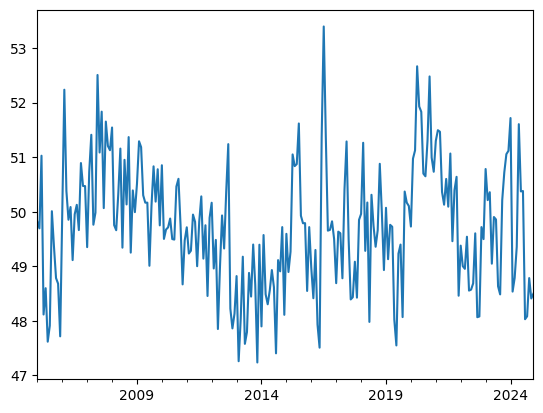

In [ ]:
df['y'].plot()

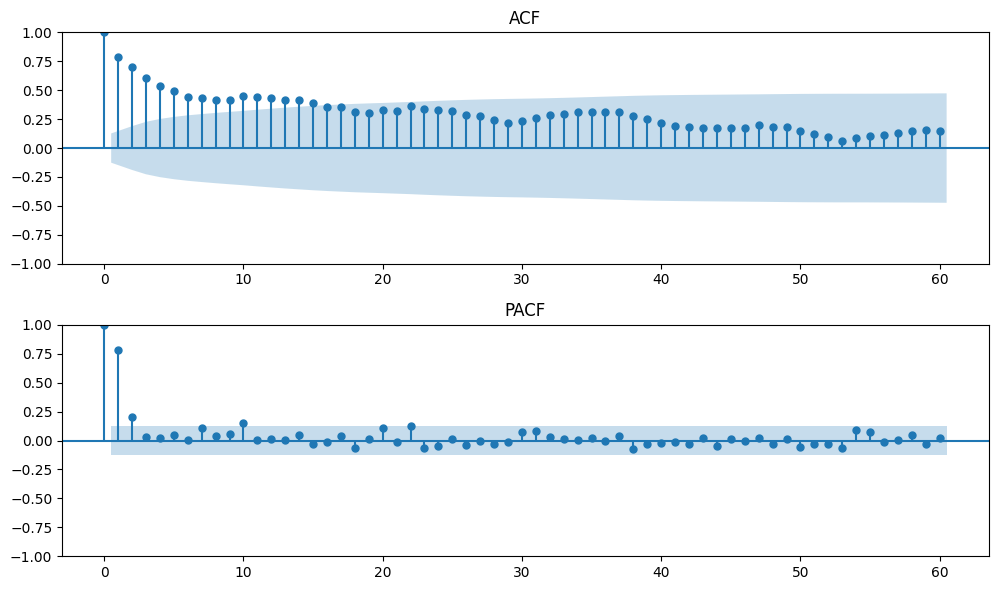

In [376]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# y is a pandas Series with DatetimeIndex and regular frequency
y = df["y"]

max_lag = 60  # choose large enough to cover a few possible seasons
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(y, lags=max_lag, ax=ax1)
ax1.set_title("ACF")

plot_pacf(y, lags=max_lag, ax=ax2, method="ywm")
ax2.set_title("PACF")

plt.tight_layout()
plt.show() 